# Demo: Soft-Prompting and Soft-Prefix Tuning

**Course:** CS 182: Deep Neural Networks  
**Topic:** Efficient Fine-Tuning with Soft Prompts

## Introduction

In the era of Large Language Models (LLMs), full fine-tuning (updating all model parameters) is often computationally prohibitive due to the immense size of the models (billions of parameters). Furthermore, we often want to adapt a single frozen model to multiple tasks without maintaining separate copies of the heavy weights.

This notebook demonstrates two **Parameter-Efficient Fine-Tuning (PEFT)** methods discussed in lecture:

1.  **Soft Prompting (Prompt Tuning):** Instead of manually engineering discrete text prompts (e.g., "Translate to French:"), we prepend a sequence of continuous, learnable vectors to the input embeddings. Only these few vectors are updated during training, while the LLM remains frozen.

2.  **Soft-Prefix Prompting (Prefix Tuning):** This extends the concept deeper into the network. Instead of just adding tokens at the input, we prepend learnable **Key-Value (KV)** pairs at *every* attention layer. This provides more expressivity by directly modulating the internal activation states of the model.

### Core Concepts

* **Discrete Prompting:** `"The capital of France is"` -> Fixed tokens, hard to optimize.
* **Soft Prompting:** $E' = [P_1, P_2, ..., P_k, E_{input}]$. We optimize $P_i$ via gradient descent. The gradients flow through the frozen model back to these input vectors.
* **Prefix Tuning:** At layer $l$, we modify Attention: $Head_l = Attention(Q, [K_{prefix}; K], [V_{prefix}; V])$. The prefix keys and values are learnable parameters.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

# Configuration
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Part 1: Building a Toy Transformer

To clearly illustrate where the "soft parameters" are injected, we will build a minimal, clean Transformer model from scratch rather than using a black-box library. This allows us to easily hook into the embedding layer (for Soft Prompting) and the Attention mechanism (for Prefix Tuning).

In [3]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_head, max_len):
        super().__init__()
        assert d_model % n_head == 0
        self.d_head = d_model // n_head
        self.n_head = n_head
        
        # Key, Query, Value projections
        self.c_attn = nn.Linear(d_model, 3 * d_model)
        self.c_proj = nn.Linear(d_model, d_model)
        
        # Causal mask
        self.register_buffer("bias", torch.tril(torch.ones(max_len, max_len))
                                     .view(1, 1, max_len, max_len))

    def forward(self, x, prefix_k=None, prefix_v=None):
        """
        x: [Batch, SeqLen, D_Model]
        prefix_k, prefix_v: [Batch, N_Head, PrefixLen, D_Head] (Optional, for Prefix Tuning)
        """
        B, T, C = x.size()
        
        # Calculate Query, Key, Value
        qkv = self.c_attn(x)
        q, k, v = qkv.split(C, dim=2)
        
        # Reshape for multi-head attention: [B, T, N_Head, D_Head] -> [B, N_Head, T, D_Head]
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)

        # --- SOFT PREFIX TUNING INJECTION ---
        # If prefix parameters are provided, prepend them to K and V
        if prefix_k is not None and prefix_v is not None:
            # prefix_k is [B, N_Head, P_Len, D_Head]
            k = torch.cat([prefix_k, k], dim=2)
            v = torch.cat([prefix_v, v], dim=2)
            
        # Adjust causal mask to account for prefix length
        full_len = k.size(2)
        # We only care about attention from the original T tokens to the (Prefix + T) tokens
        # Mask shape needs to handle this. For simplicity in this demo, we relax masking slightly 
        # or assume prefix is fully visible. 
        # We use standard scaled dot-product attention
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        
        # Causal masking (ensure we don't attend to future tokens, but can attend to all prefix tokens)
        # The mask in 'self.bias' is square [T, T]. We need [T, P+T].
        # All prefix tokens are in the "past", so they are visible.
        prefix_len = full_len - T
        causal_mask = self.bias[:, :, :T, :T]
        
        # Create a mask that allows attending to prefix (all 1s) and causal for the rest
        # Shape: [1, 1, T, P+T]
        combined_mask = torch.cat([torch.ones(1, 1, T, prefix_len).to(device), causal_mask], dim=3)
        
        att = att.masked_fill(combined_mask == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        
        y = att @ v # [B, N_Head, T, D_Head]
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

class Block(nn.Module):
    def __init__(self, d_model, n_head, max_len):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_head, max_len)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
        )

    def forward(self, x, prefix_k=None, prefix_v=None):
        x = x + self.attn(self.ln1(x), prefix_k, prefix_v)
        x = x + self.mlp(self.ln2(x))
        return x

class ToyGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_head, n_layer, max_len):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList([Block(d_model, n_head, max_len) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.max_len = max_len

    def forward(self, idx, soft_prompt_embeds=None, prefix_cache=None):
        """
        idx: [B, T] (integer tokens)
        soft_prompt_embeds: [B, P, D] (Optional, for Soft Prompting)
        prefix_cache: List of (k, v) pairs for each layer (Optional, for Prefix Tuning)
        """
        B, T = idx.size()
        
        # 1. Embeddings
        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb

        # --- SOFT PROMPTING INJECTION ---
        # If provided, prepend soft prompt embeddings to the input sequence
        if soft_prompt_embeds is not None:
            # soft_prompt_embeds is [B, P_Len, D_Model]
            # We assume soft prompt has its own positional structure or is position-agnostic for this demo
            x = torch.cat([soft_prompt_embeds, x], dim=1)
            # x is now [B, P + T, D]

        # 2. Transformer Blocks
        for i, block in enumerate(self.blocks):
            # --- PREFIX TUNING INJECTION ---
            # Retrieve specific layer prefixes if they exist
            pk, pv = (None, None)
            if prefix_cache is not None:
                pk, pv = prefix_cache[i]
            
            x = block(x, prefix_k=pk, prefix_v=pv)

        x = self.ln_f(x)
        
        # If we used soft prompting, the output sequence is longer [P+T].
        # We usually only care about predicting tokens for the real input part.
        if soft_prompt_embeds is not None:
            # Slice off the prompt part for the final classification head
            # We want logits for the original T tokens
            p_len = soft_prompt_embeds.size(1)
            x = x[:, p_len:, :]

        logits = self.head(x)
        return logits

## Part 2: Defining the Methods

Here we define the wrapper classes that manage the learnable parameters for each method. Note that in both cases, `self.model` (the LLM) is **frozen**.

### 1. Soft Prompting Wrapper
We learn a tensor of shape `[Prompt_Length, D_Model]`. In the forward pass, this is expanded to match the batch size and concatenated to the input embeddings.

In [4]:
class SoftPromptTuning(nn.Module):
    def __init__(self, frozen_model, prompt_len, d_model):
        super().__init__()
        self.model = frozen_model
        self.prompt_len = prompt_len
        
        # Learnable Soft Prompt Parameters
        # Initialized randomly (or could be from text)
        self.soft_prompt = nn.Parameter(torch.randn(1, prompt_len, d_model) * 0.02)
        
        # Freeze the main model
        for p in self.model.parameters():
            p.requires_grad = False

    def forward(self, idx):
        B = idx.size(0)
        # Expand soft prompt for batch
        prompts = self.soft_prompt.expand(B, -1, -1)
        # Pass to model via the soft_prompt_embeds argument
        return self.model(idx, soft_prompt_embeds=prompts)

### 2. Soft-Prefix Wrapper (Prefix Tuning)
We learn a set of parameters that generate Key and Value pairs for *each layer* and *each head*. 

Shape: `[Layers, 2, N_Head, Prefix_Length, D_Head]`.
The '2' corresponds to Key and Value vectors.

In [5]:
class PrefixTuning(nn.Module):
    def __init__(self, frozen_model, prefix_len, d_model, n_head, n_layer):
        super().__init__()
        self.model = frozen_model
        self.prefix_len = prefix_len
        self.n_head = n_head
        self.d_head = d_model // n_head
        self.n_layer = n_layer
        
        # Learnable Prefix Parameters: [Layer, 2 (K,V), N_Head, Prefix_Len, D_Head]
        # In practice, usually generated by a small MLP (reparameterization) for stability,
        # but for this simple demo, we learn them directly.
        self.prefix_params = nn.Parameter(torch.randn(n_layer, 2, n_head, prefix_len, self.d_head) * 0.02)
        
        # Freeze the main model
        for p in self.model.parameters():
            p.requires_grad = False

    def forward(self, idx):
        B = idx.size(0)
        
        # Prepare cache structure: List of (K, V) tuples
        prefix_cache = []
        for i in range(self.n_layer):
            # Get params for layer i
            # Shape: [2, N_Head, P_Len, D_Head]
            layer_params = self.prefix_params[i]
            k, v = layer_params[0], layer_params[1]
            
            # Expand for batch: [B, N_Head, P_Len, D_Head]
            k_batch = k.unsqueeze(0).expand(B, -1, -1, -1)
            v_batch = v.unsqueeze(0).expand(B, -1, -1, -1)
            
            prefix_cache.append((k_batch, v_batch))
            
        return self.model(idx, prefix_cache=prefix_cache)

## Part 3: Experiment Setup

**The Task:** Sequence Reversal/Shift. 
The model (pretrained randomly) obviously won't know how to do this specific task. We will try to "prompt" it to learn the task. 

Input: `[A, B, C]` -> Target: `[B, C, A]` (Cyclic shift)

We will compare:
1.  **Frozen Base Model:** (Baseline, should fail)
2.  **Soft Prompting:** Optimizing 10 input vectors.
3.  **Prefix Tuning:** Optimizing 10 prefix positions deep in the network.

In [7]:
# Model Hyperparameters
VOCAB_SIZE = 100
D_MODEL = 64
N_HEAD = 4
N_LAYER = 4
MAX_LEN = 32
PROMPT_LEN = 10

# Create base model
base_model = ToyGPT(VOCAB_SIZE, D_MODEL, N_HEAD, N_LAYER, MAX_LEN).to(device)

# Create Datasets
def generate_batch(batch_size=32, len_seq=10):
    # Generate random sequences
    data = torch.randint(0, VOCAB_SIZE, (batch_size, len_seq))
    # Task: Shift indices by 1 (Cyclic)
    targets = torch.roll(data, shifts=-1, dims=1)
    return data.to(device), targets.to(device)

# Quick sanity check
x, y = generate_batch(1, 5)
print("Input: ", x)
print("Target:", y)

Input:  tensor([[34, 95, 83, 99, 89]])
Target: tensor([[95, 83, 99, 89, 34]])


In [8]:
def train_model(model, label, steps=300):
    print(f"--- Training {label} ---")
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_history = []
    
    model.train()
    for i in range(steps):
        optimizer.zero_grad()
        inputs, targets = generate_batch()
        
        logits = model(inputs)
        
        # Flatten for CrossEntropy: [B*T, V]
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        loss.backward()
        optimizer.step()
        
        loss_history.append(loss.item())
        if i % 50 == 0:
            print(f"Step {i}: Loss {loss.item():.4f}")
            
    return loss_history

# 1. Initialize Wrappers
# Important: We copy the base model so they start from same random state for fairness
import copy
base_state = copy.deepcopy(base_model.state_dict())

# A. Soft Prompting Model
model_sp = ToyGPT(VOCAB_SIZE, D_MODEL, N_HEAD, N_LAYER, MAX_LEN).to(device)
model_sp.load_state_dict(base_state)
soft_prompt_wrapper = SoftPromptTuning(model_sp, PROMPT_LEN, D_MODEL).to(device)

# B. Prefix Tuning Model
model_pt = ToyGPT(VOCAB_SIZE, D_MODEL, N_HEAD, N_LAYER, MAX_LEN).to(device)
model_pt.load_state_dict(base_state)
prefix_tuning_wrapper = PrefixTuning(model_pt, PROMPT_LEN, D_MODEL, N_HEAD, N_LAYER).to(device)

# C. Frozen Baseline (No Tuning)
model_frozen = ToyGPT(VOCAB_SIZE, D_MODEL, N_HEAD, N_LAYER, MAX_LEN).to(device)
model_frozen.load_state_dict(base_state)
# No wrapper, just eval

<All keys matched successfully>

## Part 4: Training and Results

In [11]:
# Train Soft Prompting
hist_sp = train_model(soft_prompt_wrapper, "Soft Prompting")

# Train Prefix Tuning
hist_pt = train_model(prefix_tuning_wrapper, "Prefix Tuning")

# Baseline (Frozen)
# Just record loss over a few steps to show it doesn't improve
hist_base = []
with torch.no_grad():
    for _ in range(300):
        inputs, targets = generate_batch()
        logits = model_frozen(inputs)
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        hist_base.append(loss.item())

--- Training Soft Prompting ---
Step 0: Loss 4.7650
Step 50: Loss 4.7819
Step 100: Loss 4.7557
Step 150: Loss 4.7168
Step 200: Loss 4.7820
Step 250: Loss 4.7876
--- Training Prefix Tuning ---
Step 0: Loss 4.7030
Step 50: Loss 4.6705
Step 100: Loss 4.6271
Step 150: Loss 4.6978
Step 200: Loss 4.6405
Step 250: Loss 4.6391


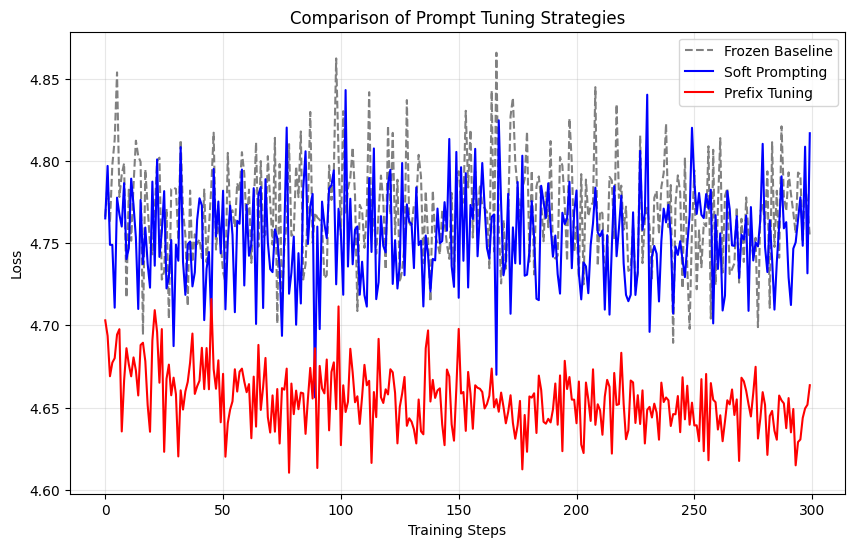

In [12]:
# Visualization
plt.figure(figsize=(10, 6))
plt.plot(hist_base, label='Frozen Baseline', color='gray', linestyle='--')
plt.plot(hist_sp, label='Soft Prompting', color='blue')
plt.plot(hist_pt, label='Prefix Tuning', color='red')
plt.title("Comparison of Prompt Tuning Strategies")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analysis of Results

1.  **Frozen Baseline:** Loss remains high and flat. The random weights of the pre-trained model are not suited for the shift task, and without updating parameters, it cannot learn.
2.  **Soft Prompting:** The loss decreases. By finding an optimal set of input vectors, the model can be "steered" to perform the task better, even though the model weights themselves are unchanged. 
3.  **Prefix Tuning:** Often converges faster or to a lower loss than Soft Prompting (depending on difficulty). By modifying the attention keys and values at *every* layer, Prefix Tuning has more control over the model's internal activations, allowing for more complex adaptation.

### Parameter Efficiency

Let's count the trainable parameters:

In [13]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = sum(p.numel() for p in base_model.parameters())
sp_params = count_parameters(soft_prompt_wrapper)
pt_params = count_parameters(prefix_tuning_wrapper)

print(f"Total Model Parameters: {total_params}")
print(f"Soft Prompt Trainable Params: {sp_params} ({sp_params/total_params:.2%})")
print(f"Prefix Tuning Trainable Params: {pt_params} ({pt_params/total_params:.2%})")

Total Model Parameters: 214912
Soft Prompt Trainable Params: 640 (0.30%)
Prefix Tuning Trainable Params: 5120 (2.38%)


## Visualizing the Learned Soft Prompt

Since the Soft Prompt lives in the same embedding space as the tokens, we can try to interpret it. In a real LLM, we might look for the "nearest neighbor" words in the vocabulary to see if the soft prompt corresponds to human-readable words (often it does not, looking more like "gibberish" that mathematically satisfies the gradient direction).

In [14]:
def interpret_soft_prompt(wrapper, model, k=3):
    # Get the learned embedding vectors
    prompt_embeds = wrapper.soft_prompt[0] # [P, D]
    
    # Get all token embeddings from the frozen model
    token_embeds = model.token_embedding.weight # [Vocab, D]
    
    print("Nearest Token Neighbors for Soft Prompt Vectors:")
    for i in range(prompt_embeds.size(0)):
        # Cosine similarity
        sim = F.cosine_similarity(prompt_embeds[i].unsqueeze(0), token_embeds)
        values, indices = torch.topk(sim, k)
        print(f"Prompt Token {i}: {indices.tolist()} (Sim: {values.detach().cpu().numpy().round(2)})")

interpret_soft_prompt(soft_prompt_wrapper, model_sp)

Nearest Token Neighbors for Soft Prompt Vectors:
Prompt Token 0: [52, 24, 8] (Sim: [0.3  0.26 0.24])
Prompt Token 1: [64, 8, 88] (Sim: [0.3  0.23 0.22])
Prompt Token 2: [74, 84, 83] (Sim: [0.28 0.26 0.24])
Prompt Token 3: [90, 2, 75] (Sim: [0.34 0.27 0.27])
Prompt Token 4: [90, 58, 75] (Sim: [0.32 0.28 0.28])
Prompt Token 5: [58, 18, 94] (Sim: [0.29 0.27 0.26])
Prompt Token 6: [58, 90, 18] (Sim: [0.3  0.27 0.27])
Prompt Token 7: [58, 90, 75] (Sim: [0.3  0.27 0.27])
Prompt Token 8: [58, 82, 75] (Sim: [0.29 0.27 0.26])
Prompt Token 9: [58, 82, 90] (Sim: [0.28 0.28 0.26])


## Summary

* **Soft Prompting** injects learnable vectors at the **Embedding** level. It is the most lightweight but has limited influence deep in the network.
* **Prefix Tuning** injects learnable vectors at the **Attention** level (Keys/Values). It is more expressive and robust for difficult tasks, as it modifies the "context" seen by every head in every layer.
* Both methods allow adapting massive models with <1% of the parameters needed for full fine-tuning.